## Analyze network after pendant nodes removal

In [1]:
import networkx as nx
from scipy.sparse import load_npz

In [4]:
G = nx.from_scipy_sparse_array(load_npz("scibert_network/results/title_embeddings/title_core.npz"))

In [5]:
len(G)

21209

IN this case a higher number of nodes is removed using the pendant nodes removal, but actually this is not true since we already had more than 3000 nodes that did not belong to the main giant component of the network. SO again, the main giant component has a very robust structure. AGain it is a lattice-like structure with a power-law-like degree distribution, but with many more nodes.

## Fit powerlaw to degree distribution

In [6]:
from scipy.sparse import load_npz
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import pareto, lognorm
import numpy as np

In [7]:
G = nx.from_scipy_sparse_array(load_npz("scibert_network/results/title_embeddings/title_scibert_adjacency_0_85.npz"))

In [8]:
degrees = list(G.degree)
degrees = [element[1] for element in degrees if element[1] != 0]

Power law exponent (minus 1) = 0.3222488537026655


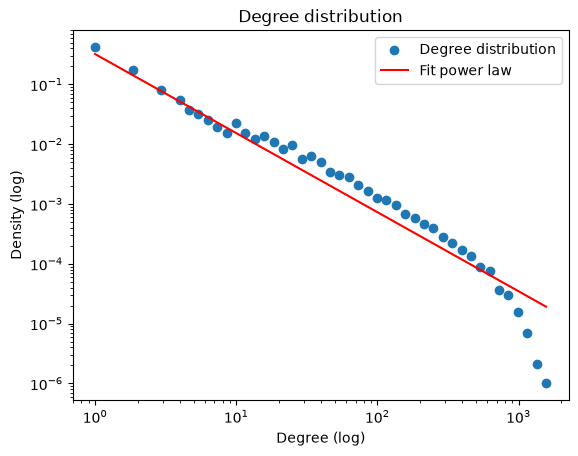

In [9]:
#fit powerlaw
plt.figure()
y, x = np.histogram(degrees, bins = np.logspace(0, np.log10(max(degrees))), density=True)
    
#the last element of y includes the last two bins of x. So x has one more element than y, which we have to cut out
plt.scatter(x[:-1], y, label = "Degree distribution")

fit_parameter, loc, scale = pareto.fit(degrees, floc = 0, fscale = 1)
#fix location and scale parameters for better fit

#define the points where the fitted function is calculated for the plot.
x_fit = np.logspace(0, np.log10(max(degrees)))
y_fit = pareto.pdf(x_fit[:-1], fit_parameter, loc = loc, scale = scale)
plt.plot(x_fit[:-1], y_fit, label = "Fit power law", color = "red")

plt.xlabel("Degree (log)")
plt.ylabel("Density (log)")
plt.title("Degree distribution")

plt.xscale("log")
plt.yscale("log")
plt.legend()
print("Power law exponent (minus 1) = " + str(fit_parameter))

This is actually much more a power law distribution, with the exponent very close to 3. Indeed, the distributions are very similar to those obtained with the Barabasi-Albert network. However, we still have a huge difference in the structure: here the removal of higher degree nodes does not change centrality measures, while this is completely different for B-A network which is much more vulnerable to attacks.

## Clustering using Louvain algorithm

In [3]:
import pickle
import networkx as nx

In [2]:
with open("scibert_network/results/title_embeddings/louvain_split", "rb") as file:
    subgraphs_list = pickle.load(file)

In [4]:
import networkx as nx
from scipy.sparse import load_npz
import pandas as pd
from collections import Counter

all_physics_topics = ["Accelerator Physics", "Applied Physics", "Atmospheric and Oceanic Physics", "Atomic and Molecular Clusters", 
                      "Atomic Physics", "Biological Physics", "Chemical Physics", "Classical Physics", "Computational Physics", 
                      "Data Analysis, Statistics and Probability", "Fluid Dynamics", "General Physics", "Geophysics", 
                      "History and Philosophy of Physics", "Instrumentation and Detectors", "Medical Physics", "Optics",
                        "Physics and Society", "Physics Education", "Plasma Physics", "Popular Physics", "Space Physics"]
all_papers = pd.read_csv("data/all_papers.csv")

In [6]:
full_graph = nx.from_scipy_sparse_array(load_npz("scibert_network/results/title_embeddings/title_scibert_adjacency_0_85.npz"))

#create list of topics and set them as node attributes
topics_list = [all_papers['primary_cathegory'][i] if all_papers['primary_cathegory'][i] in all_physics_topics 
               else all_papers['secondary_cathegory'][i] for i in range(25877)]
topics_dictionary = dict(zip(list(range(25877)), topics_list))
nx.set_node_attributes(full_graph, topics_dictionary, name = "Topic")

#create list of titles and set them as node attributes
titles_list = [all_papers['title'][i] for i in range(25877)]
titles_dictionary = dict(zip(list(range(25877)), titles_list))
nx.set_node_attributes(full_graph, titles_dictionary, name = "Title")

In [7]:
#keep only the largest component and remove the other nodes
largest_component = max(nx.connected_components(full_graph), key=len)
G = full_graph.subgraph(largest_component).copy()

In [31]:
subgraph = G.subgraph(subgraphs_list[18])

In [32]:
Counter(list(dict(nx.get_node_attributes(subgraph, name = "Topic")).values()))

Counter({'Atomic Physics': 146,
         'Applied Physics': 105,
         'Optics': 99,
         'Chemical Physics': 61,
         'Computational Physics': 42,
         'Instrumentation and Detectors': 40,
         'Physics and Society': 25,
         'Medical Physics': 20,
         'Fluid Dynamics': 17,
         'Classical Physics': 14,
         'Atmospheric and Oceanic Physics': 13,
         'Biological Physics': 9,
         'History and Philosophy of Physics': 8,
         'Plasma Physics': 8,
         'Accelerator Physics': 7,
         'Atomic and Molecular Clusters': 6,
         'General Physics': 5,
         'Physics Education': 5,
         'Space Physics': 3,
         'Geophysics': 3,
         'Data Analysis, Statistics and Probability': 2})

We have a very small number of elements in each cluster obtained using Louvain splitting. We can analyze better the length of the various subgraphs.

Better, we have some small clusters and some big clusters. We still have a prevalence of papers of one topic in some clusters, but 

In [14]:
lengths = []
for subgraph in subgraphs_list:
    S = G.subgraph(subgraph)
    lengths.append(len(S))

In [16]:
lengths

[7,
 16,
 3,
 120,
 5965,
 9,
 7,
 10,
 4146,
 52,
 2022,
 4,
 1210,
 4,
 5212,
 3,
 3,
 3269,
 638,
 3]